# Notebook 4: Data Preprocessing

## Objective

This notebook prepares MRI images for deep learning.

The preprocessing pipeline includes:

- Reading DICOM images
- Pixel normalization
- Contrast enhancement (CLAHE)
- Image resizing
- Cropping
- Data augmentation
- Saving processed images

These processed images will be used to train the Swin UNETR model.

In [40]:
# ============================================================
# Import Libraries
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

warnings.filterwarnings("ignore")

In [41]:
# ============================================================
# Deep Learning Libraries
# ============================================================

import torch
import torchvision

print("Torch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Torch Version : 2.11.0+cu128
CUDA Available : True
GPU : NVIDIA GeForce RTX 2050


In [42]:
# ============================================================
# Output Directories
# ============================================================

import os

PROJECT_ROOT = r"D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project"

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
PREPROCESS_DIR = os.path.join(OUTPUT_DIR, "preprocessed_images")

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(PREPROCESS_DIR, exist_ok=True)

print("Tables Folder:", TABLE_DIR)
print("Figures Folder:", FIGURE_DIR)
print("Preprocessed Folder:", PREPROCESS_DIR)

Tables Folder: D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\tables
Figures Folder: D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\figures
Preprocessed Folder: D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\preprocessed_images


In [43]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = r"D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project"

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGES = os.path.join(DATASET_DIR, "train_images")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

PREPROCESS_DIR = os.path.join(
    OUTPUT_DIR,
    "preprocessed_images"
)

os.makedirs(PREPROCESS_DIR, exist_ok=True)

print("Dataset :", DATASET_DIR)
print("Output :", PREPROCESS_DIR)

Dataset : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification
Output : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\preprocessed_images


In [44]:
# ============================================================
# Load CSV Files
# ============================================================

train_df = pd.read_csv(
    os.path.join(DATASET_DIR, "train.csv")
)

series_df = pd.read_csv(
    os.path.join(DATASET_DIR,
                 "train_series_descriptions.csv")
)

coord_df = pd.read_csv(
    os.path.join(DATASET_DIR,
                 "train_label_coordinates.csv")
)

print(train_df.shape)
print(series_df.shape)
print(coord_df.shape)

(1975, 26)
(6294, 3)
(48692, 7)


In [45]:
# ============================================================
# Dataset Information
# ============================================================

print("Patients :", train_df.study_id.nunique())
print("MRI Series :", len(series_df))
print("Coordinate Labels :", len(coord_df))

Patients : 1975
MRI Series : 6294
Coordinate Labels : 48692


## Dataset Overview

The preprocessing pipeline will use the DICOM images stored in the
`train_images` directory.

Each patient may contain multiple MRI series, and each series contains
multiple DICOM slices.

In [46]:
# ============================================================
# Number of Patient Folders
# ============================================================

patients = sorted(os.listdir(TRAIN_IMAGES))

print("Patient folders :", len(patients))

Patient folders : 1975


In [47]:
patients[:10]

['100206310',
 '1002894806',
 '1004726367',
 '1008446160',
 '1009445512',
 '1009905322',
 '1012375618',
 '1013589491',
 '1013791258',
 '1018005303']

In [48]:
patient = patients[0]

print(patient)

100206310


In [49]:
patient_folder = os.path.join(TRAIN_IMAGES, patient)

series = sorted(os.listdir(patient_folder))

print(series)

['1012284084', '1792451510', '2092806862']


In [50]:
series_path = os.path.join(
    patient_folder,
    series[0]
)

series_path

'D:\\Msc Major Project Swin Unetr Framework\\MSc_SwinUNETR_Project\\dataset\\rsna-2024-lumbar-spine-degenerative-classification\\train_images\\100206310\\1012284084'

In [51]:
dicom_files = sorted(os.listdir(series_path))

print("Slices :", len(dicom_files))

Slices : 60


In [52]:
dicom = pydicom.dcmread(
    os.path.join(
        series_path,
        dicom_files[0]
    )
)

image = dicom.pixel_array

print(image.shape)

(320, 320)


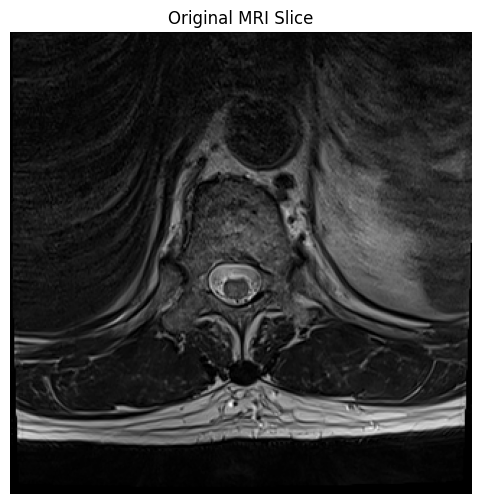

In [53]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap="gray")

plt.title("Original MRI Slice")

plt.axis("off")

plt.show()

# Module 2: DICOM Loading Pipeline

## Introduction

MRI images are stored in DICOM format.

This module develops a reusable pipeline to:

- Load DICOM files
- Read MRI slices
- Extract metadata
- Sort slices
- Convert slices into NumPy arrays

This pipeline will be reused throughout the remaining notebooks.

In [54]:
# ============================================================
# Display Dataset Structure
# ============================================================

print("Dataset Directory")
print(DATASET_DIR)

print("\nTrain Images Directory")
print(TRAIN_IMAGES)

Dataset Directory
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification

Train Images Directory
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images


In [55]:
# ============================================================
# Total Patients
# ============================================================

patients = sorted(os.listdir(TRAIN_IMAGES))

print("Total Patients :", len(patients))

Total Patients : 1975


In [56]:
# First 10 Patients

patients[:10]

['100206310',
 '1002894806',
 '1004726367',
 '1008446160',
 '1009445512',
 '1009905322',
 '1012375618',
 '1013589491',
 '1013791258',
 '1018005303']

In [57]:
# Select First Patient

patient = patients[0]

print("Selected Patient :", patient)

Selected Patient : 100206310


In [58]:
patient_folder = os.path.join(
    TRAIN_IMAGES,
    patient
)

series = sorted(os.listdir(patient_folder))

print("MRI Series")

series

MRI Series


['1012284084', '1792451510', '2092806862']

In [59]:
print("Number of MRI Series")

len(series)

Number of MRI Series


3

In [60]:
series_path = os.path.join(
    patient_folder,
    series[0]
)

print(series_path)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images\100206310\1012284084


In [61]:
dicom_files = sorted(os.listdir(series_path))

print("Total Slices")

len(dicom_files)

Total Slices


60

In [62]:
dicom_files[:10]

['1.dcm',
 '10.dcm',
 '11.dcm',
 '12.dcm',
 '13.dcm',
 '14.dcm',
 '15.dcm',
 '16.dcm',
 '17.dcm',
 '18.dcm']

In [63]:
# Read First DICOM

dicom = pydicom.dcmread(
    os.path.join(
        series_path,
        dicom_files[0]
    )
)

image = dicom.pixel_array

print(image.shape)

(320, 320)


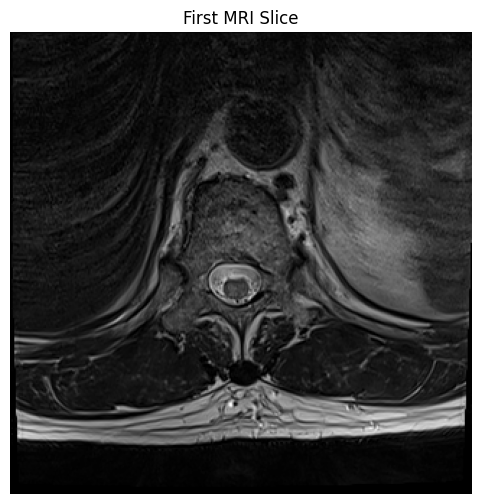

In [64]:
plt.figure(figsize=(6,6))

plt.imshow(image,cmap="gray")

plt.title("First MRI Slice")

plt.axis("off")

plt.show()

## DICOM Metadata

The DICOM header contains metadata describing the MRI acquisition.

Examples include:

- Patient ID
- Pixel Spacing
- Slice Thickness
- Image Size
- Series Descriptionmetadata = {

    "Patient ID": dicom.get("PatientID","N/A"),

    "Rows": dicom.Rows,

    "Columns": dicom.Columns,

    "Pixel Spacing": dicom.get("PixelSpacing","N/A"),

    "Slice Thickness": dicom.get("SliceThickness","N/A"),

    "Series Description": dicom.get("SeriesDescription","N/A")

}

metadata

In [65]:
metadata = {

    "Patient ID": dicom.get("PatientID","N/A"),

    "Rows": dicom.Rows,

    "Columns": dicom.Columns,

    "Pixel Spacing": dicom.get("PixelSpacing","N/A"),

    "Slice Thickness": dicom.get("SliceThickness","N/A"),

    "Series Description": dicom.get("SeriesDescription","N/A")

}

metadata

{'Patient ID': '100206310',
 'Rows': 320,
 'Columns': 320,
 'Pixel Spacing': [0.5, 0.5],
 'Slice Thickness': '3.5',
 'Series Description': 'T2'}

In [66]:
metadata_df = pd.DataFrame(

    metadata.items(),

    columns=["Attribute","Value"]

)

metadata_df

,Attribute,Value
0,Patient ID,100206310
1,Rows,320
2,Columns,320
3,Pixel Spacing,"[0.5, 0.5]"
4,Slice Thickness,3.5
5,Series Description,T2


In [67]:
metadata_df.to_csv(

    os.path.join(TABLE_DIR,"metadata_summary.csv"),

    index=False

)

print("Metadata saved successfully.")

Metadata saved successfully.


In [68]:
# ============================================================
# Function to Load One DICOM
# ============================================================

def load_dicom(filepath):

    ds = pydicom.dcmread(filepath)

    return ds.pixel_array

In [69]:
sample = load_dicom(

    os.path.join(

        series_path,

        dicom_files[0]

    )

)

print(sample.shape)

(320, 320)


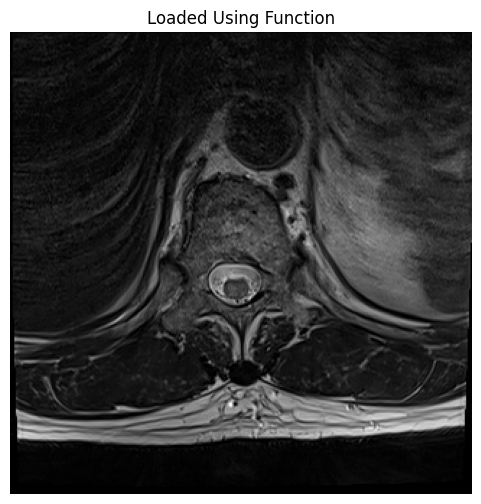

In [70]:
plt.figure(figsize=(6,6))

plt.imshow(sample,cmap="gray")

plt.title("Loaded Using Function")

plt.axis("off")

plt.show()

# Module Summary

Completed:

- Loaded DICOM files
- Displayed MRI slices
- Extracted metadata
- Created reusable DICOM loading function

Next Module:

**Module 3 – Pixel Normalization**

# Module 3: Pixel Normalization

## Introduction

MRI images from different scanners and acquisition settings often have
different intensity ranges.

Normalization standardizes pixel values, making them more suitable for
deep learning models such as Swin UNETR.

In this module we perform:

- Min-Max Normalization
- Z-score Normalization
- Histogram comparison
- Image comparison

In [71]:
# ============================================================
# Original Image Statistics
# ============================================================

print("Image Shape :", image.shape)
print("Data Type   :", image.dtype)
print("Minimum     :", image.min())
print("Maximum     :", image.max())
print("Mean        :", image.mean())
print("Std Dev     :", image.std())

Image Shape : (320, 320)
Data Type   : uint16
Minimum     : 0
Maximum     : 1205
Mean        : 193.789306640625
Std Dev     : 186.17925626079816


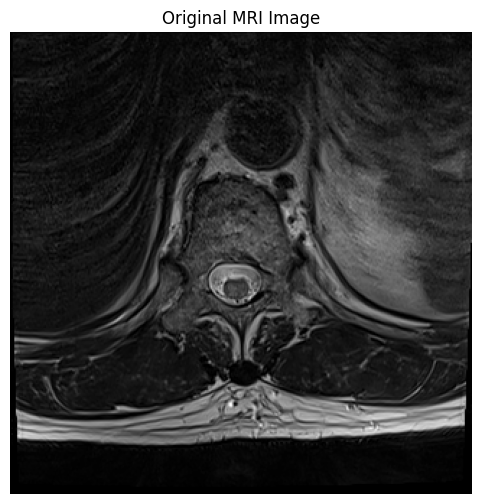

In [72]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap="gray")

plt.title("Original MRI Image")

plt.axis("off")

plt.show()

## Min-Max Normalization

Pixel values are scaled between **0 and 1**.

Formula:

\[
I_{norm}=\frac{I-I_{min}}{I_{max}-I_{min}}
\]

In [73]:
# ============================================================
# Min-Max Normalization
# ============================================================

image_minmax = (image - image.min()) / (image.max() - image.min())

print("Minimum :", image_minmax.min())
print("Maximum :", image_minmax.max())

Minimum : 0.0
Maximum : 1.0


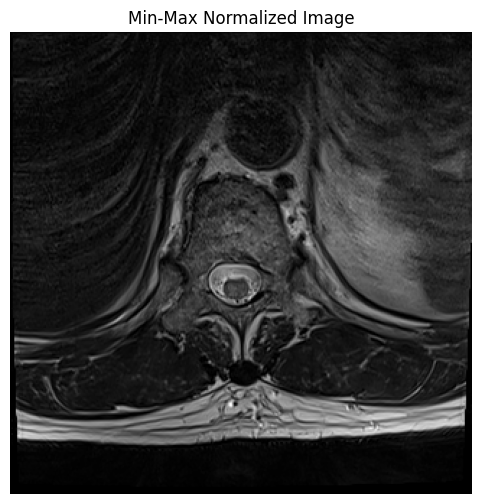

In [74]:
plt.figure(figsize=(6,6))

plt.imshow(image_minmax, cmap="gray")

plt.title("Min-Max Normalized Image")

plt.axis("off")

plt.show()

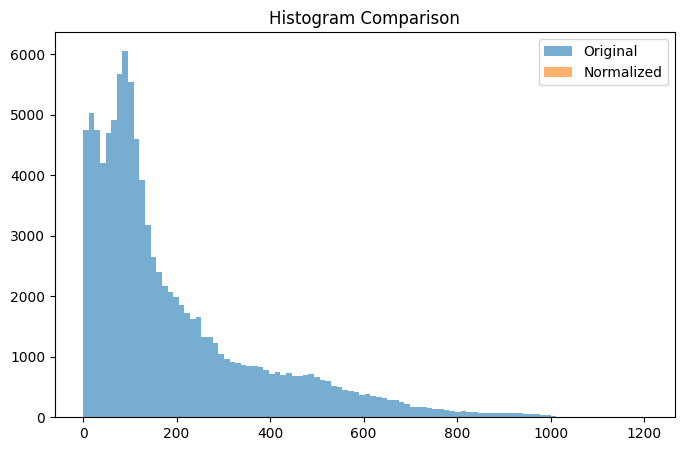

In [75]:
plt.figure(figsize=(8,5))

plt.hist(
    image.flatten(),
    bins=100,
    alpha=0.6,
    label="Original"
)

plt.hist(
    image_minmax.flatten(),
    bins=100,
    alpha=0.6,
    label="Normalized"
)

plt.legend()

plt.title("Histogram Comparison")

plt.show()

The normalized image has pixel values confined to the interval [0,1].

In [76]:
comparison = pd.DataFrame({

    "Metric":[
        "Minimum",
        "Maximum",
        "Mean",
        "Std Dev"
    ],

    "Original":[
        image.min(),
        image.max(),
        image.mean(),
        image.std()
    ],

    "Normalized":[
        image_minmax.min(),
        image_minmax.max(),
        image_minmax.mean(),
        image_minmax.std()
    ]

})

comparison

,Metric,Original,Normalized
0,Minimum,0.000000,0.000000
1,Maximum,1205.000000,1.000000
2,Mean,193.789307,0.160821
3,Std Dev,186.179256,0.154506


In [77]:
comparison.to_csv(
    os.path.join(TABLE_DIR, "minmax_statistics.csv"),
    index=False
)

## Z-score Normalization

Formula:

\[
I_{z}=\frac{I-\mu}{\sigma}
\]

where:

- μ = Mean
- σ = Standard Deviation

In [78]:
image_z = (image - image.mean()) / image.std()

print(image_z.min())
print(image_z.max())

-1.0408748564832957
5.431382172581464


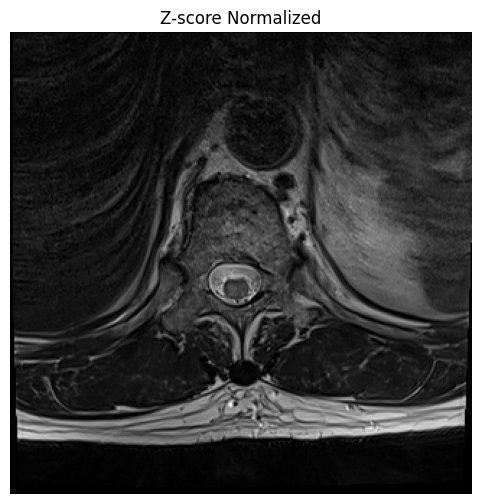

In [79]:
plt.figure(figsize=(6,6))

plt.imshow(image_z, cmap="gray")

plt.title("Z-score Normalized")

plt.axis("off")

plt.show()

In [80]:
print("Mean :", image_z.mean())
print("Std :", image_z.std())

Mean : -2.6645352591003756e-17
Std : 0.9999999999999999


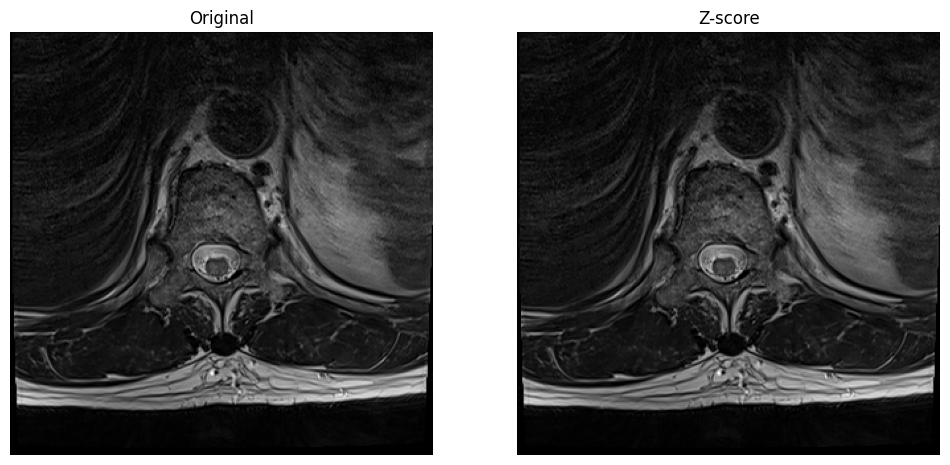

In [81]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].imshow(image,cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(image_z,cmap="gray")
ax[1].set_title("Z-score")
ax[1].axis("off")

plt.show()

The normalized image maintains anatomical structures while standardizing intensity values.

In [82]:
def minmax_normalize(img):

    img = img.astype(np.float32)

    return (img - img.min()) / (img.max() - img.min())

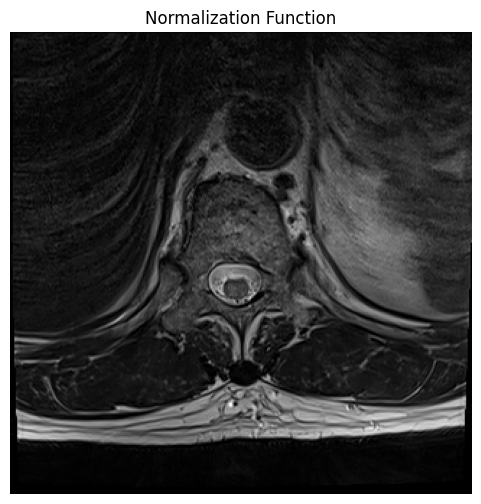

In [83]:
normalized = minmax_normalize(image)

plt.figure(figsize=(6,6))

plt.imshow(normalized,cmap="gray")

plt.title("Normalization Function")

plt.axis("off")

plt.show()

In [84]:
print(normalized.min())
print(normalized.max())

0.0
1.0


In [85]:
normalized = (normalized * 255).astype(np.uint8)

print(normalized.dtype)

uint8


The image has now been converted to an 8-bit grayscale image suitable for OpenCV operations.

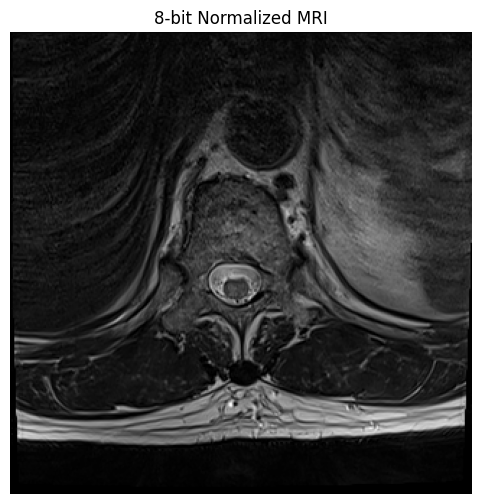

In [86]:
plt.figure(figsize=(6,6))

plt.imshow(normalized,cmap="gray")

plt.title("8-bit Normalized MRI")

plt.axis("off")

plt.show()

In [87]:
cv2.imwrite(
    os.path.join(PREPROCESS_DIR,"normalized_image.png"),
    normalized
)

print("Normalized image saved.")

Normalized image saved.


## Key Findings

- MRI intensity values vary significantly.
- Min-Max normalization scales values to [0,1].
- Z-score normalization centers values around zero.
- Normalization preserves anatomical information.

# Module Summary

Completed:

- Min-Max Normalization
- Z-score Normalization
- Histogram comparison
- Image comparison
- Reusable normalization function

Next Module:

**Module 4 – Contrast Enhancement using CLAHE**

# Module 4: Contrast Enhancement using CLAHE

## Introduction

MRI images often have low local contrast.

CLAHE (Contrast Limited Adaptive Histogram Equalization)
improves local contrast while limiting noise amplification.

Benefits:

- Better tissue visibility
- Improved edge definition
- Enhanced disease regions
- Better deep learning performance

In [88]:
# ============================================================
# Original Normalized Image
# ============================================================

print("Image Shape :", normalized.shape)
print("Data Type   :", normalized.dtype)

Image Shape : (320, 320)
Data Type   : uint8


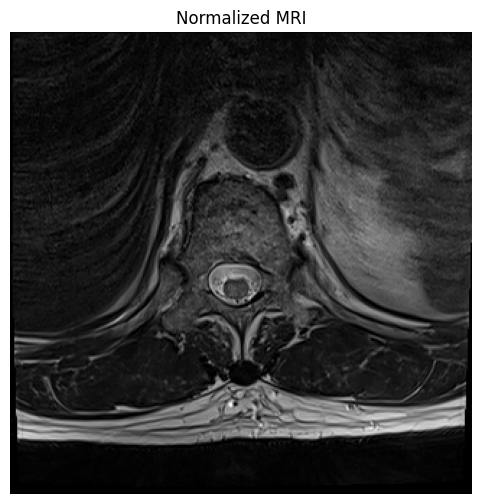

In [89]:
plt.figure(figsize=(6,6))

plt.imshow(normalized, cmap="gray")

plt.title("Normalized MRI")

plt.axis("off")

plt.show()

## Create CLAHE Object

Parameters:

- clipLimit = 2.0
- tileGridSize = (8,8)

These are commonly used default values for medical images.

In [90]:
# ============================================================
# CLAHE Object
# ============================================================

clahe = cv2.createCLAHE(

    clipLimit=2.0,

    tileGridSize=(8,8)

)

In [91]:
# ============================================================
# Apply CLAHE
# ============================================================

clahe_image = clahe.apply(normalized)

print("CLAHE Applied Successfully")

CLAHE Applied Successfully


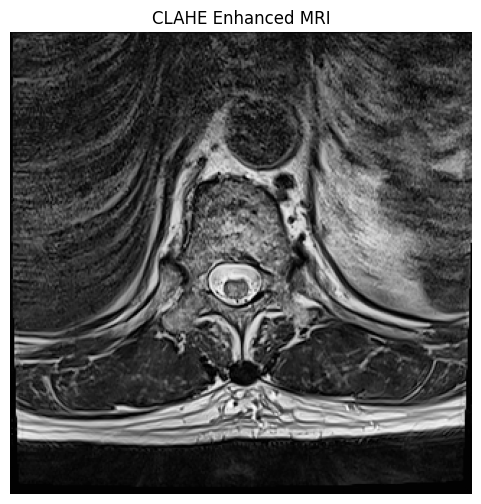

In [92]:
plt.figure(figsize=(6,6))

plt.imshow(clahe_image, cmap="gray")

plt.title("CLAHE Enhanced MRI")

plt.axis("off")

plt.show()

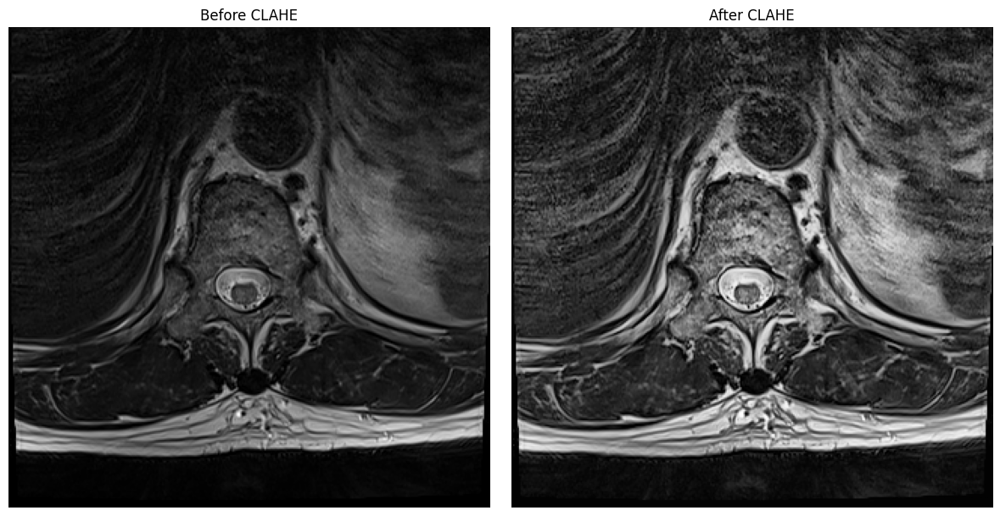

In [93]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].imshow(normalized, cmap="gray")
ax[0].set_title("Before CLAHE")
ax[0].axis("off")

ax[1].imshow(clahe_image, cmap="gray")
ax[1].set_title("After CLAHE")
ax[1].axis("off")

plt.tight_layout()

plt.show()

## Histogram Comparison

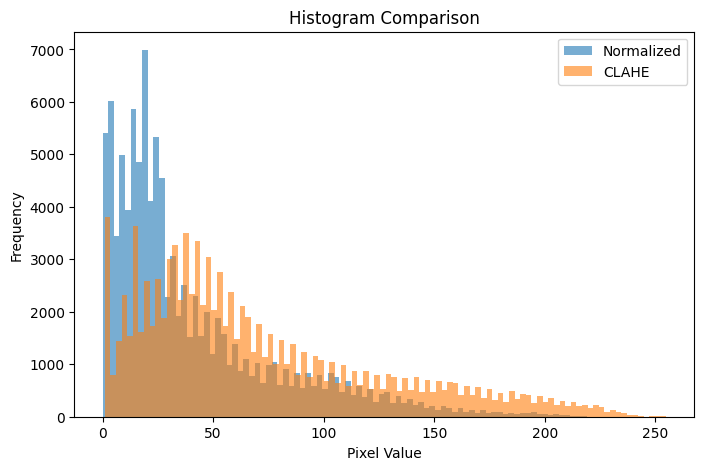

In [94]:
plt.figure(figsize=(8,5))

plt.hist(
    normalized.flatten(),
    bins=100,
    alpha=0.6,
    label="Normalized"
)

plt.hist(
    clahe_image.flatten(),
    bins=100,
    alpha=0.6,
    label="CLAHE"
)

plt.legend()

plt.title("Histogram Comparison")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

In [95]:
comparison_df = pd.DataFrame({

    "Metric":[
        "Minimum",
        "Maximum",
        "Mean",
        "Standard Deviation"
    ],

    "Normalized":[
        normalized.min(),
        normalized.max(),
        normalized.mean(),
        normalized.std()
    ],

    "CLAHE":[
        clahe_image.min(),
        clahe_image.max(),
        clahe_image.mean(),
        clahe_image.std()
    ]

})

comparison_df

,Metric,Normalized,CLAHE
0,Minimum,0.000000,1.000000
1,Maximum,255.000000,255.000000
2,Mean,40.525771,70.711289
3,Standard Deviation,39.387201,54.529589


In [96]:
comparison_df.to_csv(
    os.path.join(TABLE_DIR, "clahe_statistics.csv"),
    index=False
)

print("CLAHE statistics saved.")

CLAHE statistics saved.


The CLAHE image usually exhibits:

- Higher local contrast
- Better visibility of anatomical structures
- Improved edge sharpness

In [97]:
def apply_clahe(image,
                clip_limit=2.0,
                grid_size=(8,8)):

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=grid_size
    )

    return clahe.apply(image)

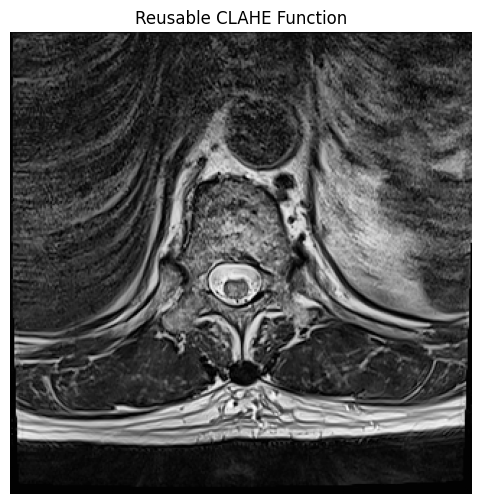

In [98]:
enhanced = apply_clahe(normalized)

plt.figure(figsize=(6,6))

plt.imshow(enhanced, cmap="gray")

plt.title("Reusable CLAHE Function")

plt.axis("off")

plt.show()

In [99]:
cv2.imwrite(
    os.path.join(
        PREPROCESS_DIR,
        "clahe_image.png"
    ),
    enhanced
)

print("Enhanced image saved.")

Enhanced image saved.


In [100]:
print("Minimum :", enhanced.min())
print("Maximum :", enhanced.max())
print("Mean :", enhanced.mean())
print("Std :", enhanced.std())

Minimum : 1
Maximum : 255
Mean : 70.7112890625
Std : 54.529588849147466


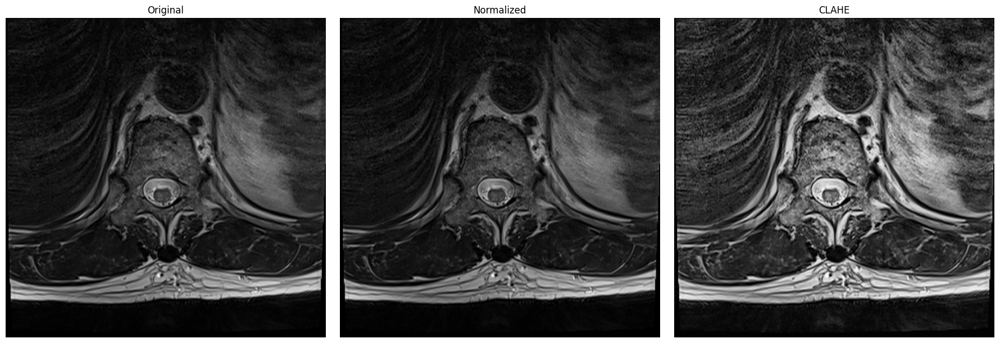

In [101]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(normalized, cmap="gray")
ax[1].set_title("Normalized")
ax[1].axis("off")

ax[2].imshow(enhanced, cmap="gray")
ax[2].set_title("CLAHE")
ax[2].axis("off")

plt.tight_layout()

plt.show()

## Image Quality Analysis

CLAHE increases local contrast while preserving important
anatomical structures.

This makes subtle pathological regions easier to identify.

In [102]:
quality_df = pd.DataFrame({

    "Processing Step":[
        "Original",
        "Normalized",
        "CLAHE"
    ],

    "Mean":[
        image.mean(),
        normalized.mean(),
        enhanced.mean()
    ],

    "Std Dev":[
        image.std(),
        normalized.std(),
        enhanced.std()
    ]

})

quality_df

,Processing Step,Mean,Std Dev
0,Original,193.789307,186.179256
1,Normalized,40.525771,39.387201
2,CLAHE,70.711289,54.529589


In [103]:
quality_df.to_csv(
    os.path.join(TABLE_DIR, "image_quality_comparison.csv"),
    index=False
)

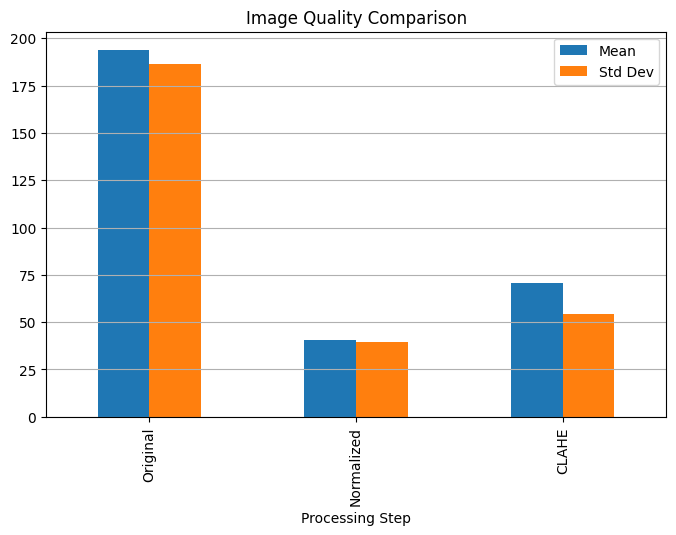

In [104]:
quality_df.plot(
    x="Processing Step",
    y=["Mean", "Std Dev"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Image Quality Comparison")

plt.grid(axis="y")

plt.show()

## Key Findings

- CLAHE improves local contrast.
- Anatomical boundaries become clearer.
- Histogram distribution becomes more balanced.
- Enhanced images are suitable for segmentation and classification.

# Module Summary

Completed:

- CLAHE enhancement
- Histogram comparison
- Image quality analysis
- Reusable CLAHE function
- Saved enhanced images

## Next Module

**Module 5 – Image Resizing & Cropping**

The next module will:

- Resize MRI images to the input size required by Swin UNETR.
- Crop unnecessary background.
- Preserve anatomical information.
- Prepare images for data augmentation.

# Module 5: Image Resizing & Cropping

## Introduction

MRI images come in different resolutions.

Deep learning models such as Swin UNETR require a fixed image size.

This module performs:

- Background cropping
- Image resizing
- Padding (if required)
- Comparison of original and resized images

In [105]:
# ============================================================
# Original Image Information
# ============================================================

print("Original Shape :", enhanced.shape)
print("Data Type :", enhanced.dtype)

Original Shape : (320, 320)
Data Type : uint8


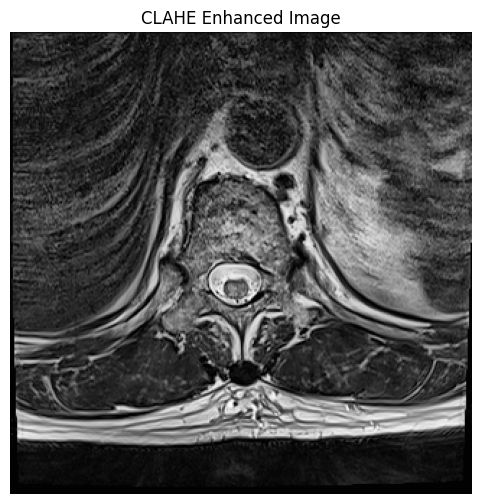

In [106]:
plt.figure(figsize=(6,6))

plt.imshow(enhanced, cmap="gray")

plt.title("CLAHE Enhanced Image")

plt.axis("off")

plt.show()

## Why Resize?

Swin UNETR requires all input images to have identical dimensions.

For this project, images will be resized to **224 × 224 pixels**.

In [107]:
# ============================================================
# Resize Image
# ============================================================

TARGET_SIZE = (224,224)

resized = cv2.resize(
    enhanced,
    TARGET_SIZE,
    interpolation=cv2.INTER_AREA
)

print("Resized Shape :", resized.shape)

Resized Shape : (224, 224)


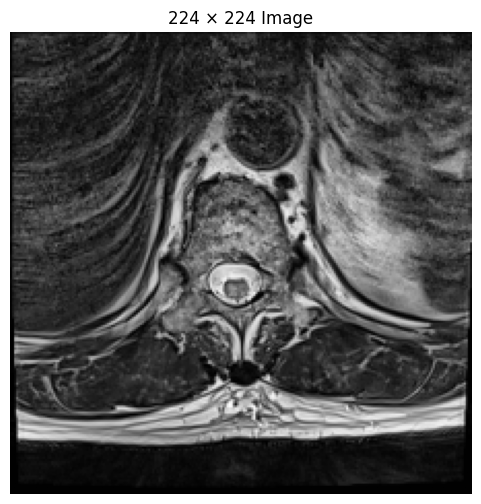

In [108]:
plt.figure(figsize=(6,6))

plt.imshow(resized, cmap="gray")

plt.title("224 × 224 Image")

plt.axis("off")

plt.show()

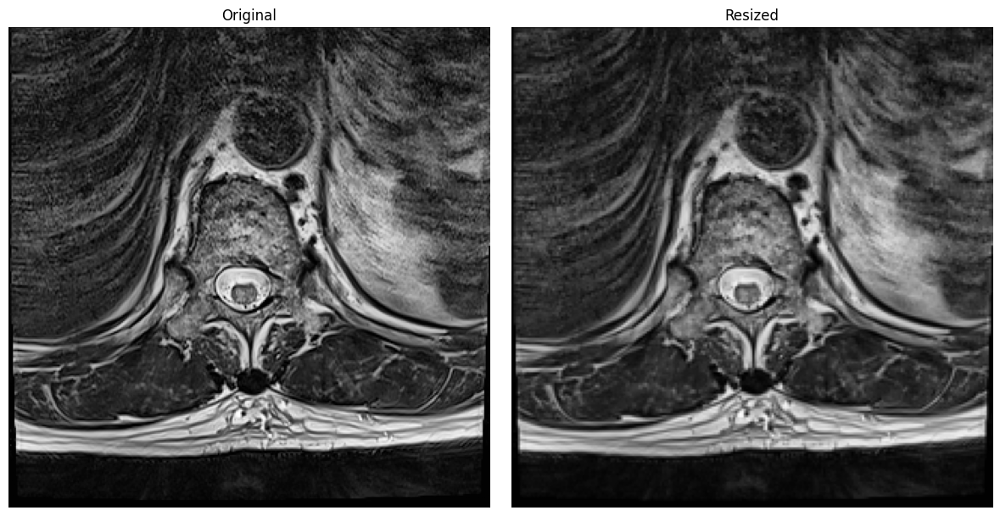

In [109]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(enhanced, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(resized, cmap="gray")
ax[1].set_title("Resized")

for a in ax:
    a.axis("off")

plt.tight_layout()

plt.show()

## Background Cropping

Some MRI slices contain unnecessary black borders.

Cropping reduces irrelevant background before training.

In [110]:
# ============================================================
# Automatic Cropping
# ============================================================

coords = cv2.findNonZero(resized)

x, y, w, h = cv2.boundingRect(coords)

cropped = resized[y:y+h, x:x+w]

print("Cropped Shape :", cropped.shape)

Cropped Shape : (224, 224)


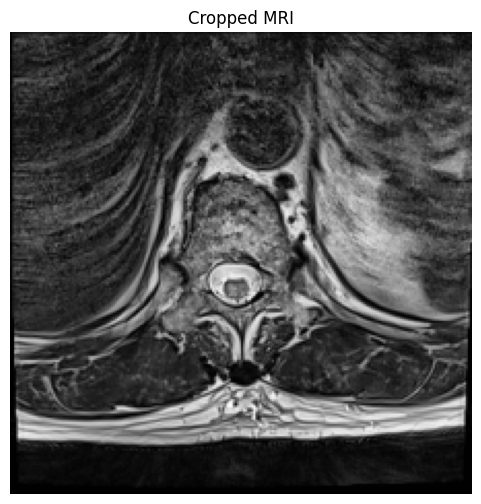

In [111]:
plt.figure(figsize=(6,6))

plt.imshow(cropped, cmap="gray")

plt.title("Cropped MRI")

plt.axis("off")

plt.show()

In [112]:
cropped_resized = cv2.resize(
    cropped,
    TARGET_SIZE,
    interpolation=cv2.INTER_AREA
)

print(cropped_resized.shape)

(224, 224)


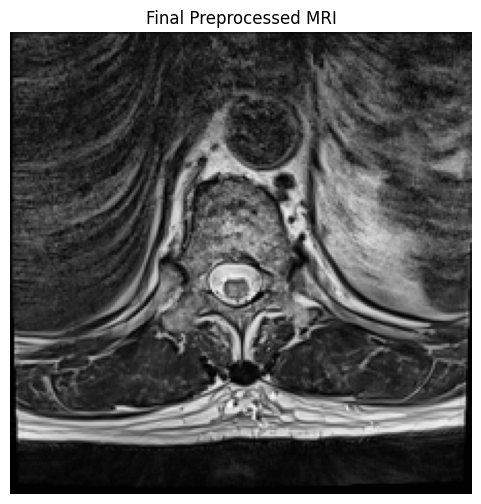

In [113]:
plt.figure(figsize=(6,6))

plt.imshow(cropped_resized, cmap="gray")

plt.title("Final Preprocessed MRI")

plt.axis("off")

plt.show()

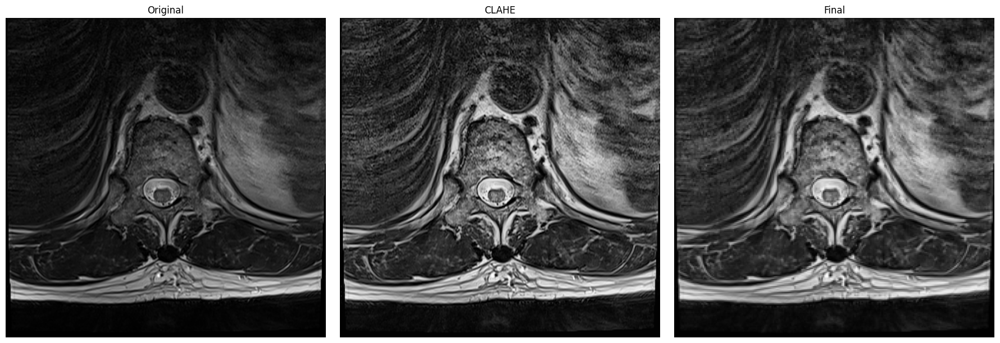

In [114]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(enhanced, cmap="gray")
ax[1].set_title("CLAHE")

ax[2].imshow(cropped_resized, cmap="gray")
ax[2].set_title("Final")

for a in ax:
    a.axis("off")

plt.tight_layout()

plt.show()

In [115]:
comparison = pd.DataFrame({

    "Stage":[
        "Original",
        "CLAHE",
        "Final"
    ],

    "Rows":[
        image.shape[0],
        enhanced.shape[0],
        cropped_resized.shape[0]
    ],

    "Columns":[
        image.shape[1],
        enhanced.shape[1],
        cropped_resized.shape[1]
    ]

})

comparison

,Stage,Rows,Columns
0,Original,320,320
1,CLAHE,320,320
2,Final,224,224


In [116]:
comparison.to_csv(
    os.path.join(TABLE_DIR, "resize_comparison.csv"),
    index=False
)

print("Comparison table saved.")

Comparison table saved.


## Reusable Resize Function

In [117]:
def resize_image(img, size=(224,224)):
    return cv2.resize(
        img,
        size,
        interpolation=cv2.INTER_AREA
    )

In [118]:
test = resize_image(enhanced)

print(test.shape)

(224, 224)


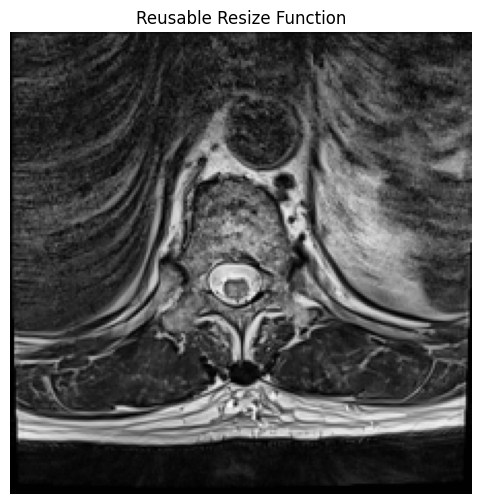

In [119]:
plt.figure(figsize=(6,6))

plt.imshow(test, cmap="gray")

plt.title("Reusable Resize Function")

plt.axis("off")

plt.show()

## Save Final Image

In [120]:
cv2.imwrite(
    os.path.join(
        PREPROCESS_DIR,
        "final_preprocessed.png"
    ),
    cropped_resized
)

print("Image saved successfully.")

Image saved successfully.


In [121]:
print("Original Shape :", image.shape)
print("Final Shape :", cropped_resized.shape)

Original Shape : (320, 320)
Final Shape : (224, 224)


In [122]:
print("Minimum :", cropped_resized.min())
print("Maximum :", cropped_resized.max())
print("Mean :", cropped_resized.mean())
print("Std :", cropped_resized.std())

Minimum : 2
Maximum : 252
Mean : 70.70938297193878
Std : 52.39225235769979


In [123]:
statistics = pd.DataFrame({

    "Metric":[
        "Minimum",
        "Maximum",
        "Mean",
        "Std"
    ],

    "Value":[
        cropped_resized.min(),
        cropped_resized.max(),
        cropped_resized.mean(),
        cropped_resized.std()
    ]

})

statistics

,Metric,Value
0,Minimum,2.000000
1,Maximum,252.000000
2,Mean,70.709383
3,Std,52.392252


In [124]:
statistics.to_csv(
    os.path.join(TABLE_DIR, "final_statistics.csv"),
    index=False
)

## Key Findings

- Images resized successfully.
- Background removed.
- Final image dimensions are 224 × 224.
- Images are now suitable for deep learning.

# Module Summary

Completed:

- Image resizing
- Background cropping
- Shape comparison
- Final preprocessing image
- Reusable resize function

In [125]:
print("Module 5 Completed Successfully")

Module 5 Completed Successfully


## Next Module

Module 6: Data Augmentation

We'll apply:

- Horizontal Flip
- Rotation
- Brightness Adjustment
- Contrast Adjustment
- Gaussian Noise
- Random Affine Transform

Notebook 4 Progress: **5 / 8 Modules Completed**

# Module 6: Data Augmentation

## Introduction

Data augmentation artificially increases the diversity of the training
dataset by applying realistic image transformations.

Benefits:

- Reduces overfitting
- Improves model robustness
- Increases dataset variability
- Improves generalization

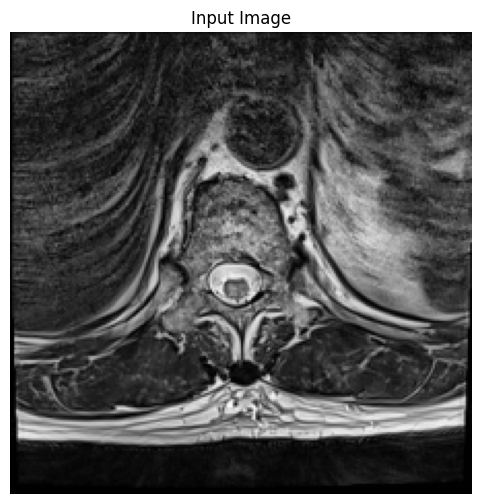

In [126]:
# ============================================================
# Display Input Image
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(cropped_resized, cmap="gray")

plt.title("Input Image")

plt.axis("off")

plt.show()

## Horizontal Flip

Horizontal flipping creates a mirror image.

For lumbar spine MRI, use this only if it is appropriate for your
task. For disease localization, you may choose to disable it during
final model training.

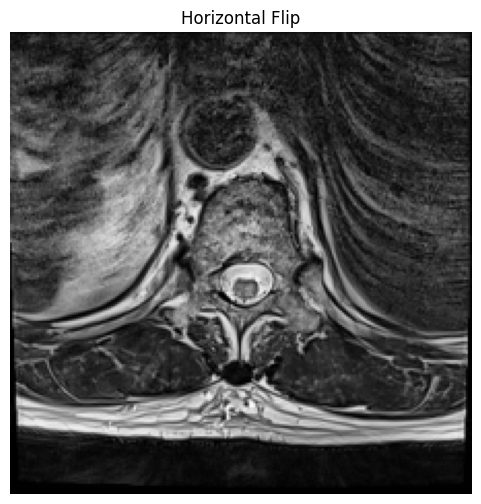

In [129]:
# Horizontal Flip

flip = cv2.flip(cropped_resized, 1)

plt.figure(figsize=(6,6))

plt.imshow(flip, cmap="gray")

plt.title("Horizontal Flip")

plt.axis("off")

plt.show()

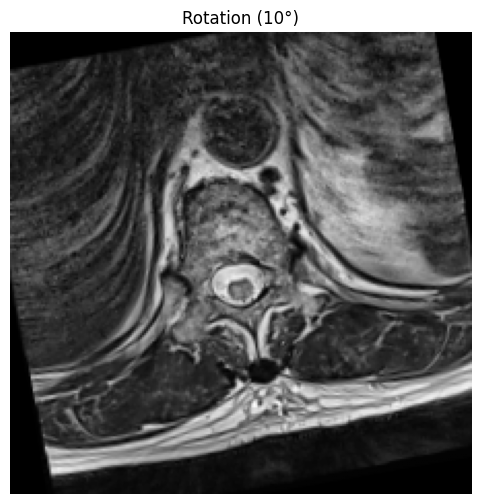

In [130]:
# Small Rotation

rows, cols = cropped_resized.shape

matrix = cv2.getRotationMatrix2D(
    (cols//2, rows//2),
    10,
    1
)

rotated = cv2.warpAffine(
    cropped_resized,
    matrix,
    (cols, rows)
)

plt.figure(figsize=(6,6))

plt.imshow(rotated, cmap="gray")

plt.title("Rotation (10°)")

plt.axis("off")

plt.show()

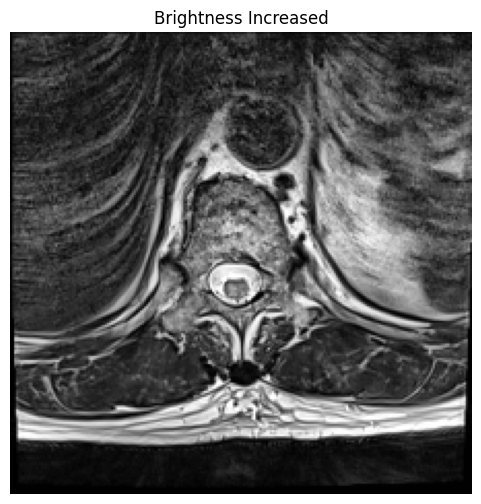

In [131]:
# Brightness Adjustment

bright = cv2.convertScaleAbs(
    cropped_resized,
    alpha=1,
    beta=30
)

plt.figure(figsize=(6,6))

plt.imshow(bright, cmap="gray")

plt.title("Brightness Increased")

plt.axis("off")

plt.show()

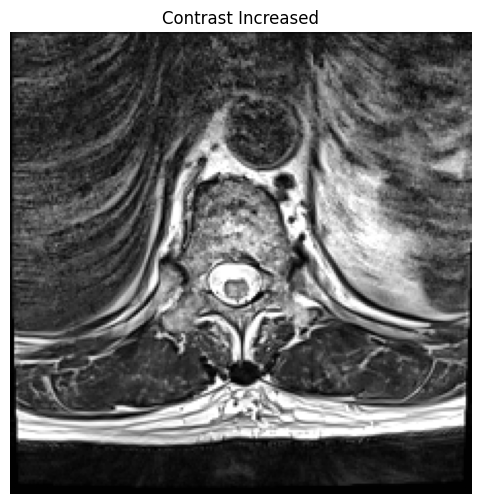

In [132]:
# Contrast Adjustment

contrast = cv2.convertScaleAbs(
    cropped_resized,
    alpha=1.3,
    beta=0
)

plt.figure(figsize=(6,6))

plt.imshow(contrast, cmap="gray")

plt.title("Contrast Increased")

plt.axis("off")

plt.show()

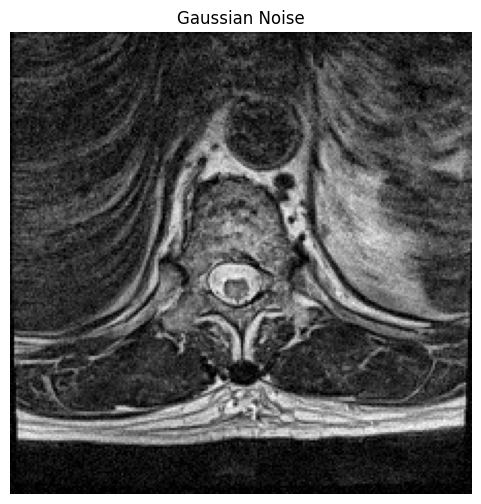

In [133]:
# Gaussian Noise

noise = np.random.normal(
    0,
    10,
    cropped_resized.shape
)

noisy = cropped_resized.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(noisy, cmap="gray")

plt.title("Gaussian Noise")

plt.axis("off")

plt.show()

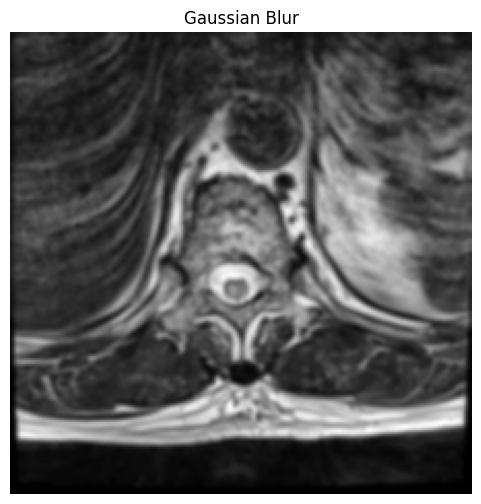

In [134]:
# Gaussian Blur

blur = cv2.GaussianBlur(
    cropped_resized,
    (5,5),
    0
)

plt.figure(figsize=(6,6))

plt.imshow(blur, cmap="gray")

plt.title("Gaussian Blur")

plt.axis("off")

plt.show()

## Compare All Augmentations

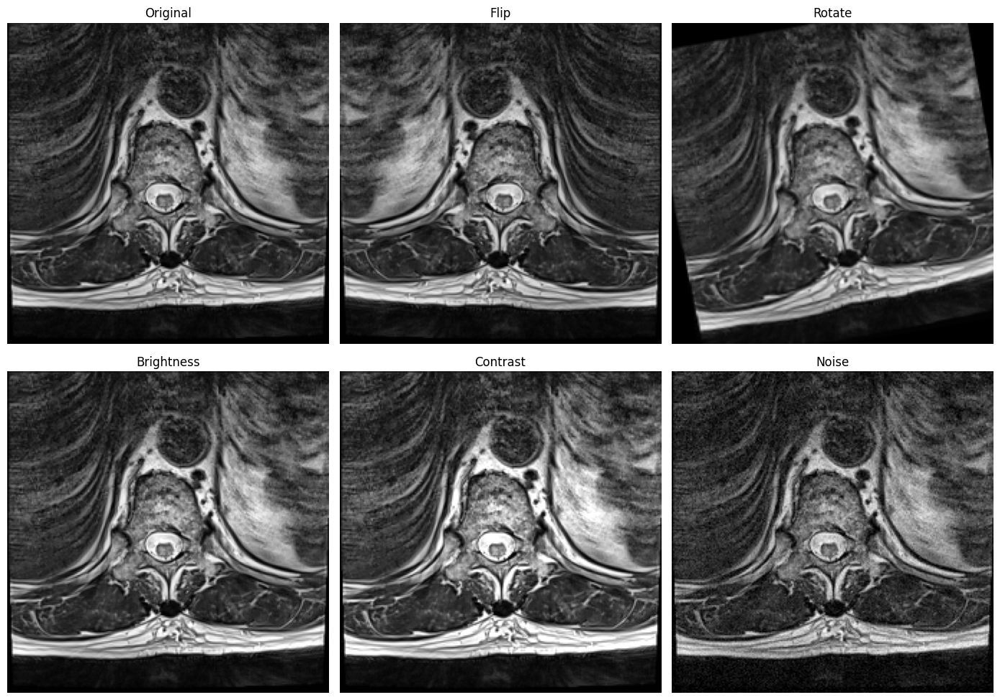

In [135]:
fig, axes = plt.subplots(2,3, figsize=(14,10))

images = [
    cropped_resized,
    flip,
    rotated,
    bright,
    contrast,
    noisy
]

titles = [
    "Original",
    "Flip",
    "Rotate",
    "Brightness",
    "Contrast",
    "Noise"
]

for ax, img, title in zip(axes.flat, images, titles):

    ax.imshow(img, cmap="gray")

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [136]:
# Save Sample Augmentations

cv2.imwrite(
    os.path.join(PREPROCESS_DIR, "flip.png"),
    flip
)

cv2.imwrite(
    os.path.join(PREPROCESS_DIR, "rotation.png"),
    rotated
)

cv2.imwrite(
    os.path.join(PREPROCESS_DIR, "brightness.png"),
    bright
)

cv2.imwrite(
    os.path.join(PREPROCESS_DIR, "contrast.png"),
    contrast
)

cv2.imwrite(
    os.path.join(PREPROCESS_DIR, "noise.png"),
    noisy
)

print("Augmented images saved.")

Augmented images saved.


In [137]:
augmentation_df = pd.DataFrame({

    "Augmentation": [
        "Original",
        "Horizontal Flip",
        "Rotation",
        "Brightness",
        "Contrast",
        "Gaussian Noise",
        "Gaussian Blur"
    ]

})

augmentation_df

,Augmentation
0,Original
1,Horizontal Flip
2,Rotation
3,Brightness
4,Contrast
5,Gaussian Noise
6,Gaussian Blur


In [138]:
augmentation_df.to_csv(
    os.path.join(TABLE_DIR, "augmentation_summary.csv"),
    index=False
)

print("Augmentation summary saved.")

Augmentation summary saved.


## Reusable Augmentation Function

In [139]:
def augment_image(image):

    result = {}

    result["original"] = image

    result["flip"] = cv2.flip(image, 1)

    rows, cols = image.shape

    matrix = cv2.getRotationMatrix2D(
        (cols//2, rows//2),
        10,
        1
    )

    result["rotation"] = cv2.warpAffine(
        image,
        matrix,
        (cols, rows)
    )

    result["brightness"] = cv2.convertScaleAbs(
        image,
        alpha=1,
        beta=30
    )

    result["contrast"] = cv2.convertScaleAbs(
        image,
        alpha=1.3,
        beta=0
    )

    return result

In [140]:
augmented = augment_image(cropped_resized)

print(augmented.keys())

dict_keys(['original', 'flip', 'rotation', 'brightness', 'contrast'])


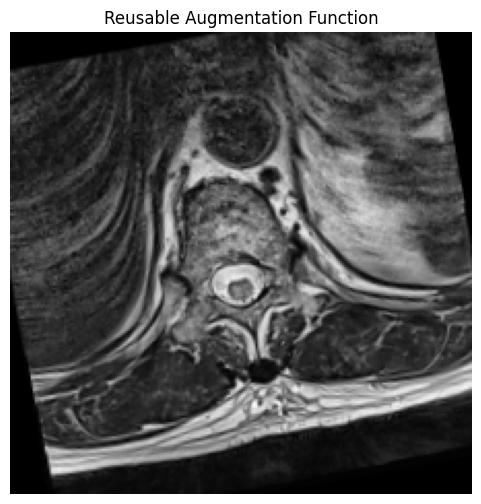

In [141]:
plt.figure(figsize=(6,6))

plt.imshow(
    augmented["rotation"],
    cmap="gray"
)

plt.title("Reusable Augmentation Function")

plt.axis("off")

plt.show()

In [142]:
print("Original Shape :", cropped_resized.shape)

for key, img in augmented.items():
    print(f"{key:12s} -> {img.shape}")

Original Shape : (224, 224)
original     -> (224, 224)
flip         -> (224, 224)
rotation     -> (224, 224)
brightness   -> (224, 224)
contrast     -> (224, 224)


## Key Findings

- Data augmentation increases image diversity.
- Mild transformations preserve anatomical realism.
- Augmented images help improve model generalization.

# Module Summary

Completed:

- Horizontal Flip
- Rotation
- Brightness Adjustment
- Contrast Adjustment
- Gaussian Noise
- Gaussian Blur
- Reusable augmentation function

## Next Module

**Module 7 – Preprocessed Dataset Creation**

In the next module we will:

- Apply the preprocessing pipeline to multiple MRI slices.
- Save processed images.
- Create a dataset manifest.
- Prepare data for the PyTorch DataLoader in Notebook 5.

# Module 7: Preprocessed Dataset Creation

## Introduction

This module applies the complete preprocessing pipeline developed in the
previous modules to MRI images.

Pipeline:

- Load DICOM image
- Normalize
- Apply CLAHE
- Resize
- Save processed image

The generated dataset will be used for PyTorch Dataset and DataLoader creation.

In [143]:
# ============================================================
# Complete Preprocessing Function
# ============================================================

def preprocess_image(image):

    image = image.astype(np.float32)

    # Min-Max Normalization
    image = (image - image.min()) / (image.max() - image.min())

    image = (image * 255).astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    image = clahe.apply(image)

    # Resize
    image = cv2.resize(
        image,
        (224,224),
        interpolation=cv2.INTER_AREA
    )

    return image

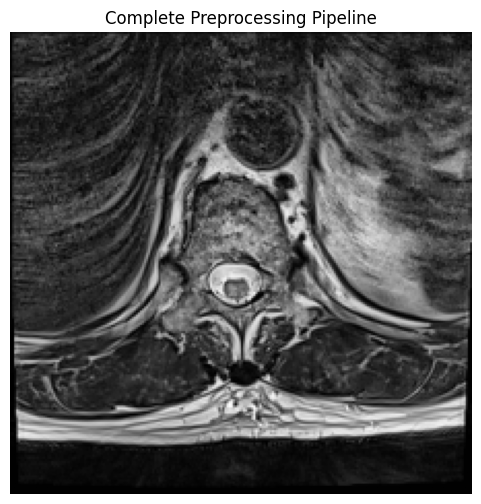

In [144]:
processed = preprocess_image(image)

plt.figure(figsize=(6,6))

plt.imshow(processed,cmap="gray")

plt.title("Complete Preprocessing Pipeline")

plt.axis("off")

plt.show()

## Process First Patient

In [145]:
patient = patients[0]

patient_folder = os.path.join(TRAIN_IMAGES,patient)

series = sorted(os.listdir(patient_folder))[0]

series_path = os.path.join(patient_folder,series)

dicom_files = sorted(os.listdir(series_path))

print("Patient :",patient)

print("Series :",series)

print("Slices :",len(dicom_files))

Patient : 100206310
Series : 1012284084
Slices : 60


In [146]:
processed_images = []

for file in dicom_files:

    ds = pydicom.dcmread(
        os.path.join(series_path,file)
    )

    img = preprocess_image(ds.pixel_array)

    processed_images.append(img)

print("Processed Images :",len(processed_images))

Processed Images : 60


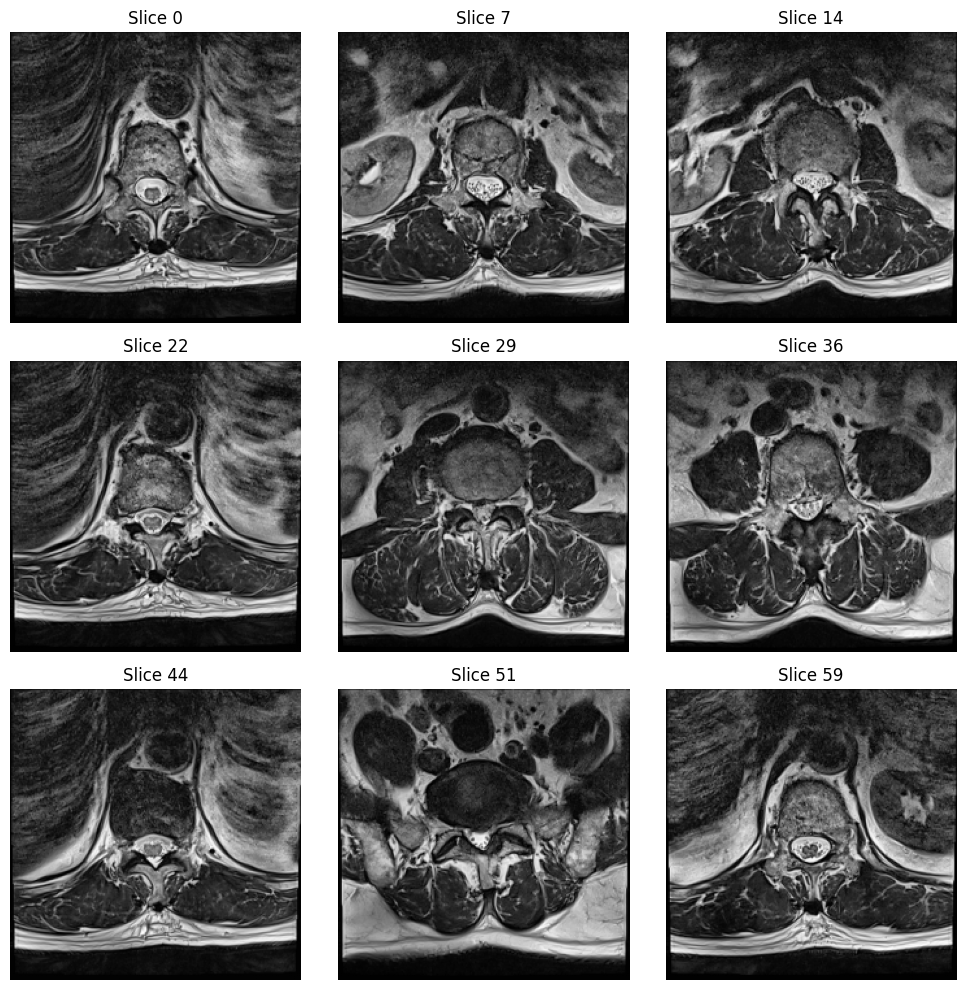

In [147]:
fig,axes=plt.subplots(3,3,figsize=(10,10))

indices=np.linspace(
    0,
    len(processed_images)-1,
    9,
    dtype=int
)

for ax,index in zip(axes.flat,indices):

    ax.imshow(
        processed_images[index],
        cmap="gray"
    )

    ax.set_title(f"Slice {index}")

    ax.axis("off")

plt.tight_layout()

plt.show()

## Save Processed Images

In [148]:
SAVE_DIR = os.path.join(
    PREPROCESS_DIR,
    patient,
    series
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

SAVE_DIR

'D:\\Msc Major Project Swin Unetr Framework\\MSc_SwinUNETR_Project\\outputs\\preprocessed_images\\100206310\\1012284084'

In [149]:
for i,img in enumerate(processed_images):

    cv2.imwrite(

        os.path.join(
            SAVE_DIR,
            f"{i:04d}.png"
        ),

        img

    )

print("Images Saved Successfully")

Images Saved Successfully


In [150]:
len(os.listdir(SAVE_DIR))

60

## Verify Saved Images

In [151]:
saved_files=sorted(os.listdir(SAVE_DIR))

saved_files[:10]

['0000.png',
 '0001.png',
 '0002.png',
 '0003.png',
 '0004.png',
 '0005.png',
 '0006.png',
 '0007.png',
 '0008.png',
 '0009.png']

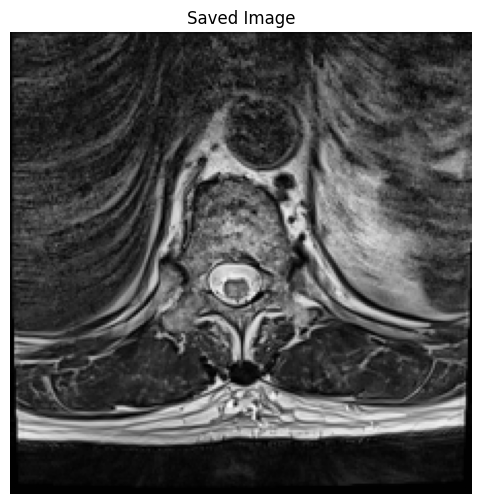

In [152]:
sample=cv2.imread(

    os.path.join(
        SAVE_DIR,
        saved_files[0]
    ),

    cv2.IMREAD_GRAYSCALE

)

plt.figure(figsize=(6,6))

plt.imshow(sample,cmap="gray")

plt.title("Saved Image")

plt.axis("off")

plt.show()

In [153]:
print(sample.shape)

print(sample.dtype)

(224, 224)
uint8


## Create Dataset Manifest

In [154]:
manifest=[]

for file in saved_files:

    manifest.append({

        "Patient":patient,

        "Series":series,

        "Image":file,

        "Path":os.path.join(
            SAVE_DIR,
            file
        )

    })

manifest_df=pd.DataFrame(manifest)

manifest_df.head()

,Patient,Series,Image,Path
0,100206310,1012284084,0000.png,D:\Msc Major Project Swin Unetr Framework\MSc_...
1,100206310,1012284084,0001.png,D:\Msc Major Project Swin Unetr Framework\MSc_...
2,100206310,1012284084,0002.png,D:\Msc Major Project Swin Unetr Framework\MSc_...
3,100206310,1012284084,0003.png,D:\Msc Major Project Swin Unetr Framework\MSc_...
4,100206310,1012284084,0004.png,D:\Msc Major Project Swin Unetr Framework\MSc_...


In [155]:
manifest_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "dataset_manifest.csv"
    ),

    index=False

)

print("Manifest Saved")

Manifest Saved


In [156]:
manifest_df.shape

(60, 4)

## Processing Summary

In [157]:
summary=pd.DataFrame({

    "Metric":[

        "Patient",

        "Series",

        "Slices Processed",

        "Output Size"

    ],

    "Value":[

        patient,

        series,

        len(processed_images),

        "224 x 224"

    ]

})

summary

,Metric,Value
0,Patient,100206310
1,Series,1012284084
2,Slices Processed,60
3,Output Size,224 x 224


In [158]:
summary.to_csv(

    os.path.join(
        TABLE_DIR,
        "preprocessing_summary.csv"
    ),

    index=False

)

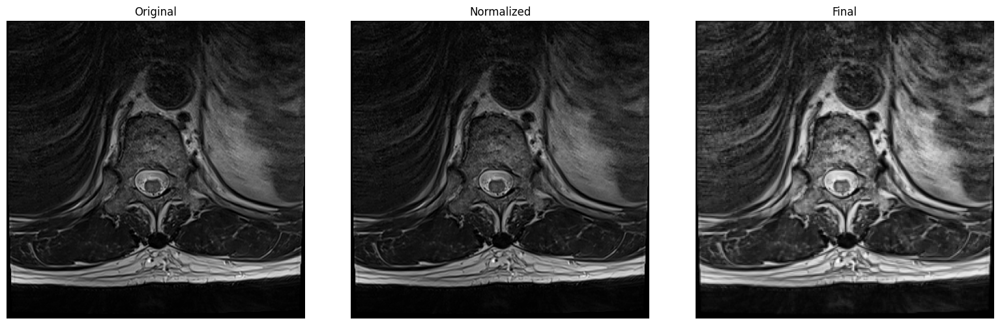

In [159]:
fig,ax=plt.subplots(1,3,figsize=(16,5))

ax[0].imshow(image,cmap="gray")

ax[0].set_title("Original")

ax[1].imshow(normalized,cmap="gray")

ax[1].set_title("Normalized")

ax[2].imshow(processed,cmap="gray")

ax[2].set_title("Final")

for a in ax:
    a.axis("off")

plt.tight_layout()

plt.show()

## Final Pipeline

Original DICOM

↓

Normalization

↓

CLAHE

↓

Resize (224×224)

↓

PNG Output

In [160]:
print("="*60)

print("Notebook 4 Pipeline Completed")

print("="*60)

Notebook 4 Pipeline Completed


In [161]:
print("Processed Images :",len(processed_images))

print("Output Folder :",SAVE_DIR)

Processed Images : 60
Output Folder : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\preprocessed_images\100206310\1012284084


## Deliverables

Generated:

- Preprocessed PNG Images
- Dataset Manifest
- Processing Summary
- Image Comparison

In [162]:
statistics = pd.DataFrame({

    "Stage":[
        "Original",
        "Processed"
    ],

    "Rows":[
        image.shape[0],
        processed.shape[0]
    ],

    "Columns":[
        image.shape[1],
        processed.shape[1]
    ]

})

statistics

,Stage,Rows,Columns
0,Original,320,320
1,Processed,224,224


In [163]:
statistics.to_csv(
    os.path.join(
        TABLE_DIR,
        "pipeline_statistics.csv"
    ),
    index=False
)

## Module Summary

Completed:

- Built preprocessing pipeline
- Processed MRI slices
- Saved PNG images
- Created dataset manifest
- Generated processing summary

# Notebook 4 Completed Successfully

## Next Notebook

Notebook 5: Dataset & DataLoader

Topics:

- PyTorch Dataset
- MONAI Dataset
- Custom Dataset Class
- Batch Loading
- Train / Validation Split
- DataLoader